# Retail Sales Analysis with AI
**IBM SkillsBuild – Data Analytics with AI Academic Internship (BharatCares x AICTE)**

**Author:** Bavisetti Mamatha

**Objective:** Analyse retail order data to find what drives sales and profit, group customers into segments using machine learning (K-Means), and predict order profit using a Random Forest model.

**Workflow:** 1) Load data → 2) Clean data → 3) Exploratory analysis → 4) Customer segmentation (AI) → 5) Profit prediction (AI) → 6) Insights

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load the Dataset
The dataset is a **simulated retail sales dataset** (about 5,000 orders, 2023–2025) created with a fixed random seed so results are reproducible. It mimics a typical superstore: orders, customers, regions, categories, discounts, sales and profit. It also contains a few deliberate missing values and duplicate rows so that the data-cleaning step is meaningful.

In [2]:
import os

CSV_FILE = "retail_sales_data.csv"

def generate_dataset(n_orders=5000, seed=42):
    rng = np.random.default_rng(seed)

    # Order dates with seasonality (more orders in Oct-Dec)
    all_days = pd.date_range("2023-01-01", "2025-12-31")
    weights = np.where(all_days.month.isin([10, 11, 12]), 1.8, 1.0)
    weights = weights / weights.sum()
    order_dates = rng.choice(all_days, size=n_orders, p=weights)

    customer_ids = rng.integers(1, 801, size=n_orders)
    segment_map = {c: rng.choice(["Consumer", "Corporate", "Home Office"], p=[0.5, 0.3, 0.2]) for c in range(1, 801)}
    region_map = {c: rng.choice(["North", "South", "East", "West", "Central"]) for c in range(1, 801)}

    category = rng.choice(["Furniture", "Technology", "Office Supplies"], size=n_orders, p=[0.25, 0.25, 0.5])
    price_range = {"Furniture": (80, 600), "Technology": (100, 1200), "Office Supplies": (5, 150)}
    base_margin = {"Furniture": 0.10, "Technology": 0.22, "Office Supplies": 0.18}

    unit_price = np.array([rng.uniform(*price_range[c]) for c in category]).round(2)
    quantity = rng.integers(1, 11, size=n_orders)
    discount = rng.choice([0.0, 0.05, 0.10, 0.20, 0.30], size=n_orders, p=[0.40, 0.20, 0.20, 0.12, 0.08])

    sales = (quantity * unit_price * (1 - discount)).round(2)
    margin = np.array([base_margin[c] for c in category]) - discount * 0.9 + rng.normal(0, 0.05, n_orders)
    profit = (sales * margin).round(2)

    df = pd.DataFrame({
        "Order_ID": [f"ORD-{100000 + i}" for i in range(n_orders)],
        "Order_Date": pd.to_datetime(order_dates),
        "Customer_ID": [f"CUST-{c:04d}" for c in customer_ids],
        "Segment": [segment_map[c] for c in customer_ids],
        "Region": [region_map[c] for c in customer_ids],
        "Category": category,
        "Quantity": quantity,
        "Unit_Price": unit_price,
        "Discount": discount,
        "Sales": sales,
        "Profit": profit,
    }).sort_values("Order_Date").reset_index(drop=True)

    # Add small data-quality issues on purpose
    miss_idx = rng.choice(df.index, size=60, replace=False)
    df.loc[miss_idx[:30], "Region"] = np.nan
    df.loc[miss_idx[30:], "Discount"] = np.nan
    dupes = df.sample(25, random_state=seed)
    df = pd.concat([df, dupes], ignore_index=True)
    return df

if not os.path.exists(CSV_FILE):
    generate_dataset().to_csv(CSV_FILE, index=False)
    print("Dataset created:", CSV_FILE)

df = pd.read_csv(CSV_FILE)
print("Shape:", df.shape)
df.head()

Dataset created: retail_sales_data.csv
Shape: (5025, 11)


     Order_ID  Order_Date Customer_ID      Segment   Region         Category  \
0  ORD-101157  2023-01-01   CUST-0681     Consumer    North  Office Supplies   
1  ORD-101836  2023-01-01   CUST-0637    Corporate  Central  Office Supplies   
2  ORD-103502  2023-01-01   CUST-0350    Corporate    South  Office Supplies   
3  ORD-101220  2023-01-02   CUST-0484  Home Office    North        Furniture   
4  ORD-103150  2023-01-02   CUST-0183     Consumer    North        Furniture   

   Quantity  Unit_Price  Discount    Sales  Profit  
0         6       35.86       0.0   215.16   38.14  
1         3       80.30       0.3   168.63  -26.65  
2         7       99.84       0.0   698.88  138.89  
3        10      325.92       0.1  2933.28  -27.74  
4         2      483.46       0.1   870.23    5.33  

## 2. Understand the Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_ID     5025 non-null   str    
 1   Order_Date   5025 non-null   str    
 2   Customer_ID  5025 non-null   str    
 3   Segment      5025 non-null   str    
 4   Region       4995 non-null   str    
 5   Category     5025 non-null   str    
 6   Quantity     5025 non-null   int64  
 7   Unit_Price   5025 non-null   float64
 8   Discount     4995 non-null   float64
 9   Sales        5025 non-null   float64
 10  Profit       5025 non-null   float64
dtypes: float64(4), int64(1), str(6)
memory usage: 432.0 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe().round(2)

Missing values per column:
Order_ID        0
Order_Date      0
Customer_ID     0
Segment         0
Region         30
Category        0
Quantity        0
Unit_Price      0
Discount       30
Sales           0
Profit          0
dtype: int64

Duplicate rows: 25


       Quantity  Unit_Price  Discount     Sales   Profit
count   5025.00     5025.00   4995.00   5025.00  5025.00
mean       5.57      289.57      0.08   1503.68   174.07
std        2.89      296.88      0.09   1923.57   383.63
min        1.00        5.08      0.00      4.56 -1224.41
25%        3.00       78.52      0.00    271.37     8.50
50%        6.00      140.36      0.05    725.65    53.91
75%        8.00      450.10      0.10   1947.80   181.97
max       10.00     1199.69      0.30  11965.20  3723.83

## 3. Data Cleaning
Steps: remove duplicate rows, convert dates, fill missing `Region` using the customer's known region, fill missing `Discount` with the median, and create new columns (Year, Month, Profit Margin).

In [5]:
# 1. Remove duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates removed:", before - len(df))

# 2. Convert dates
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# 3. Fill missing Region using the same customer's other orders, else the most common region
cust_region = df.dropna(subset=["Region"]).groupby("Customer_ID")["Region"].agg(lambda s: s.mode().iloc[0])
df["Region"] = df["Region"].fillna(df["Customer_ID"].map(cust_region))
df["Region"] = df["Region"].fillna(df["Region"].mode().iloc[0])

# 4. Fill missing Discount with the median
df["Discount"] = df["Discount"].fillna(df["Discount"].median())

# 5. Feature engineering
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Year_Month"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()
df["Profit_Margin_%"] = (df["Profit"] / df["Sales"] * 100).round(2)

print("Remaining missing values:", int(df.isnull().sum().sum()))
print("Clean dataset shape:", df.shape)
df.head()

Duplicates removed: 25
Remaining missing values: 0
Clean dataset shape: (5000, 15)


     Order_ID Order_Date Customer_ID      Segment   Region         Category  \
0  ORD-101157 2023-01-01   CUST-0681     Consumer    North  Office Supplies   
1  ORD-101836 2023-01-01   CUST-0637    Corporate  Central  Office Supplies   
2  ORD-103502 2023-01-01   CUST-0350    Corporate    South  Office Supplies   
3  ORD-101220 2023-01-02   CUST-0484  Home Office    North        Furniture   
4  ORD-103150 2023-01-02   CUST-0183     Consumer    North        Furniture   

   Quantity  Unit_Price  Discount    Sales  Profit  Year  Month Year_Month  \
0         6       35.86       0.0   215.16   38.14  2023      1 2023-01-01   
1         3       80.30       0.3   168.63  -26.65  2023      1 2023-01-01   
2         7       99.84       0.0   698.88  138.89  2023      1 2023-01-01   
3        10      325.92       0.1  2933.28  -27.74  2023      1 2023-01-01   
4         2      483.46       0.1   870.23    5.33  2023      1 2023-01-01   

   Profit_Margin_%  
0            17.73  
1           -1

## 4. Exploratory Data Analysis (EDA)
### 4.1 Business summary

In [6]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
print(f"Total orders       : {len(df):,}")
print(f"Total customers    : {df['Customer_ID'].nunique():,}")
print(f"Total sales        : {total_sales:,.0f}")
print(f"Total profit       : {total_profit:,.0f}")
print(f"Overall margin     : {total_profit / total_sales * 100:.2f}%")
print(f"Loss-making orders : {(df['Profit'] < 0).mean() * 100:.1f}%")

Total orders       : 5,000
Total customers    : 799
Total sales        : 7,510,891
Total profit       : 867,587
Overall margin     : 11.55%
Loss-making orders : 17.2%


### 4.2 Monthly sales trend

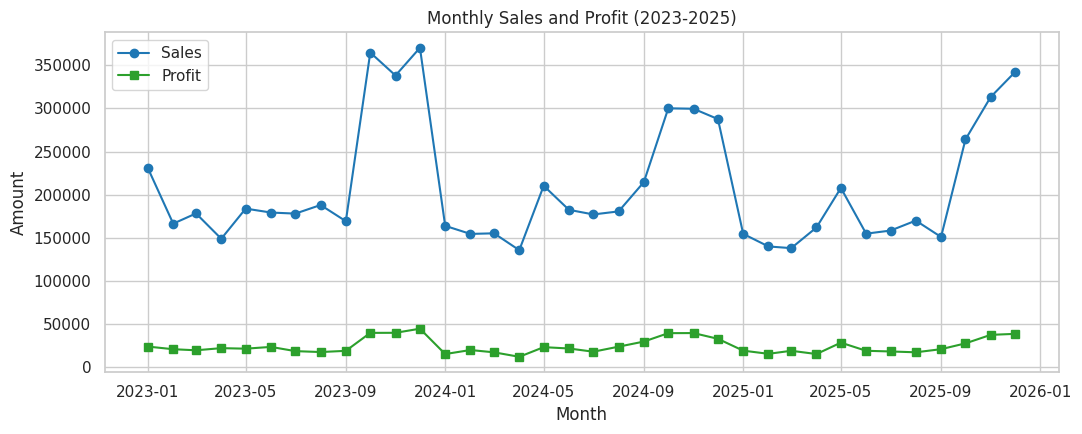

In [7]:
monthly = df.groupby("Year_Month")[["Sales", "Profit"]].sum()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly["Sales"], marker="o", label="Sales", color="#1f77b4")
ax.plot(monthly.index, monthly["Profit"], marker="s", label="Profit", color="#2ca02c")
ax.set_title("Monthly Sales and Profit (2023-2025)")
ax.set_xlabel("Month"); ax.set_ylabel("Amount")
ax.legend()
plt.tight_layout()
plt.savefig("figures/01_monthly_trend.png", dpi=150)
plt.show()

### 4.3 Sales and profit by category and region

                     Sales    Profit
Category                            
Technology       4130644.0  656966.0
Furniture        2386538.0   89456.0
Office Supplies   993709.0  121165.0


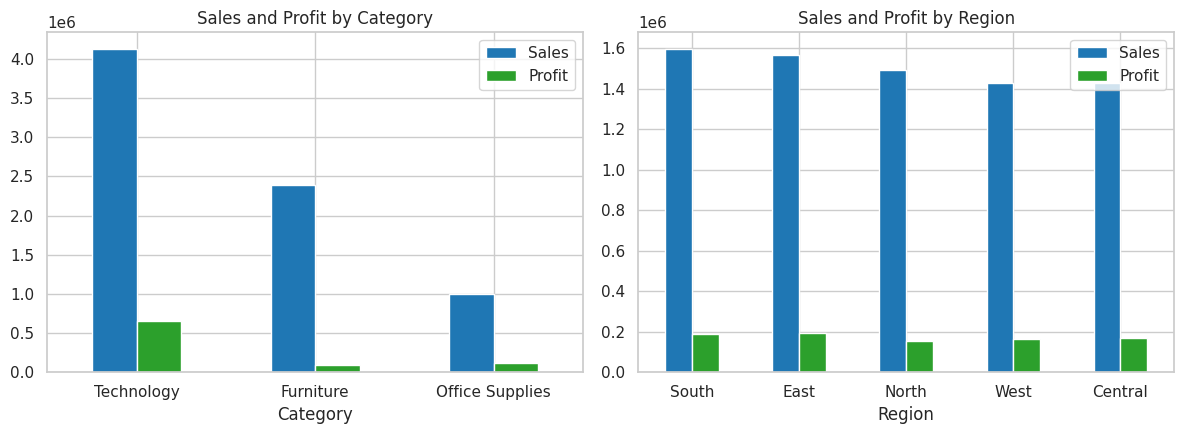

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cat = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
cat.plot(kind="bar", ax=axes[0], color=["#1f77b4", "#2ca02c"])
axes[0].set_title("Sales and Profit by Category"); axes[0].tick_params(axis="x", rotation=0)

reg = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
reg.plot(kind="bar", ax=axes[1], color=["#1f77b4", "#2ca02c"])
axes[1].set_title("Sales and Profit by Region"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("figures/02_category_region.png", dpi=150)
plt.show()

print(cat.round(0))

### 4.4 Does discounting hurt profit?

          Orders  Avg_Profit  Avg_Margin_pct
Discount                                    
0.00        2008      288.33           16.88
0.05        1018      201.95           12.31
0.10         989      133.67            8.22
0.20         609      -16.60           -1.40
0.30         376     -103.90           -9.53


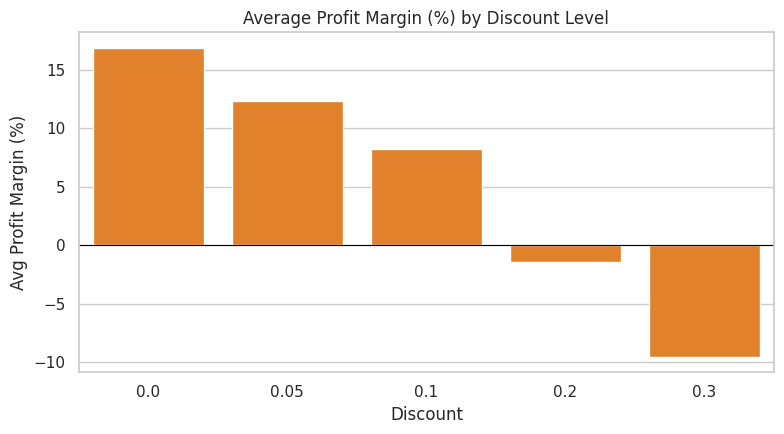

In [9]:
disc = df.groupby("Discount").agg(Orders=("Order_ID", "count"),
                                  Avg_Profit=("Profit", "mean"),
                                  Avg_Margin_pct=("Profit_Margin_%", "mean")).round(2)
print(disc)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=disc.index.astype(str), y=disc["Avg_Margin_pct"], ax=ax, color="#ff7f0e")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Average Profit Margin (%) by Discount Level")
ax.set_xlabel("Discount"); ax.set_ylabel("Avg Profit Margin (%)")
plt.tight_layout()
plt.savefig("figures/03_discount_margin.png", dpi=150)
plt.show()

### 4.5 Correlation between numeric columns

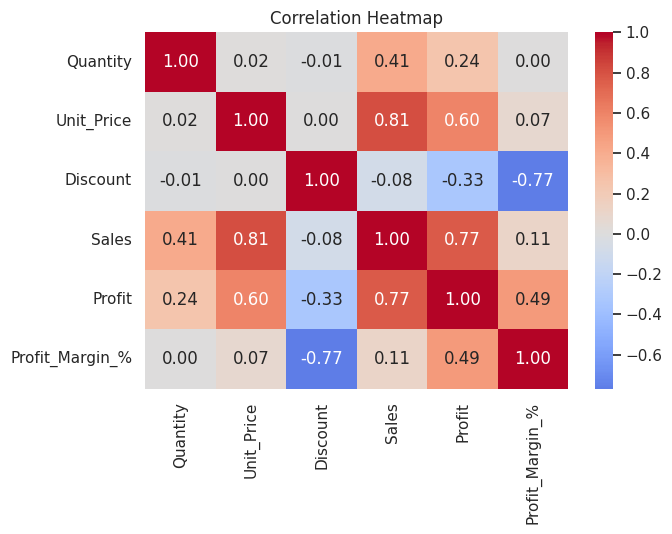

In [10]:
num_cols = ["Quantity", "Unit_Price", "Discount", "Sales", "Profit", "Profit_Margin_%"]
plt.figure(figsize=(7, 5.5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/04_correlation.png", dpi=150)
plt.show()

## 5. AI Part 1 – Customer Segmentation (K-Means Clustering)
We summarise each customer using **RFM** features – *Recency* (days since last order), *Frequency* (number of orders) and *Monetary* (total sales) – and group similar customers with K-Means.

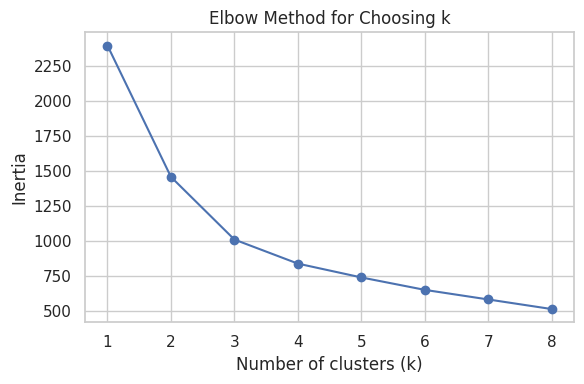

In [11]:
snapshot = df["Order_Date"].max() + pd.Timedelta(days=1)
rfm = df.groupby("Customer_ID").agg(
    Recency=("Order_Date", lambda d: (snapshot - d.max()).days),
    Frequency=("Order_ID", "count"),
    Monetary=("Sales", "sum"),
).reset_index()

X_rfm = StandardScaler().fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# Elbow method to choose k
inertia = []
for k in range(1, 9):
    inertia.append(KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_rfm).inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 9), inertia, marker="o")
plt.title("Elbow Method for Choosing k")
plt.xlabel("Number of clusters (k)"); plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("figures/05_elbow.png", dpi=150)
plt.show()

In [12]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(X_rfm)

profile = rfm.groupby("Cluster").agg(Customers=("Customer_ID", "count"),
                                     Avg_Recency_days=("Recency", "mean"),
                                     Avg_Orders=("Frequency", "mean"),
                                     Avg_Spend=("Monetary", "mean")).round(1)

# Give business-friendly names: highest spend = Loyal High-Value, highest recency = At-Risk, other = Regular
names = {}
names[profile["Avg_Spend"].idxmax()] = "Loyal High-Value"
remaining = profile.drop(index=list(names.keys()))
names[remaining["Avg_Recency_days"].idxmax()] = "At-Risk / Inactive"
for c in profile.index:
    names.setdefault(c, "Regular")
rfm["Segment_Name"] = rfm["Cluster"].map(names)
profile["Segment_Name"] = profile.index.map(names)
print(profile)

         Customers  Avg_Recency_days  Avg_Orders  Avg_Spend  \
Cluster                                                       
0              130             445.3         4.0     5610.9   
1              297              90.7         8.6    15257.7   
2              372              92.5         5.2     6048.3   

               Segment_Name  
Cluster                      
0        At-Risk / Inactive  
1          Loyal High-Value  
2                   Regular  


Segment_Name
Regular               372
Loyal High-Value      297
At-Risk / Inactive    130
Name: count, dtype: int64


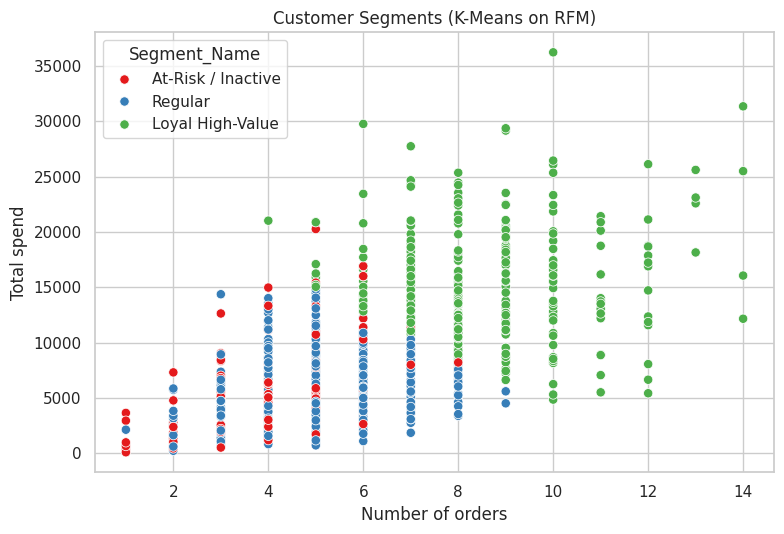

In [13]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Segment_Name", palette="Set1", s=45, ax=ax)
ax.set_title("Customer Segments (K-Means on RFM)")
ax.set_xlabel("Number of orders"); ax.set_ylabel("Total spend")
plt.tight_layout()
plt.savefig("figures/06_segments.png", dpi=150)
plt.show()

print(rfm["Segment_Name"].value_counts())

## 6. AI Part 2 – Predicting Order Profit (Machine Learning)
We train two regression models to predict the **profit of an order** from order details, and compare them: Linear Regression (baseline) and Random Forest.

In [14]:
features = ["Category", "Region", "Segment", "Quantity", "Unit_Price", "Discount", "Month"]
X = pd.get_dummies(df[features], columns=["Category", "Region", "Segment"], drop_first=True)
y = df["Profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", X_train.shape[0], "| Testing rows:", X_test.shape[0])

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
}

results = []
preds = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    preds[name] = p
    results.append({"Model": name,
                    "R2": round(r2_score(y_test, p), 3),
                    "MAE": round(mean_absolute_error(y_test, p), 2),
                    "RMSE": round(np.sqrt(mean_squared_error(y_test, p)), 2)})
results_df = pd.DataFrame(results)
results_df

Training rows: 4000 | Testing rows: 1000


               Model     R2     MAE    RMSE
0  Linear Regression  0.588  152.68  248.80
1      Random Forest  0.882   65.66  132.95

Best model: Random Forest


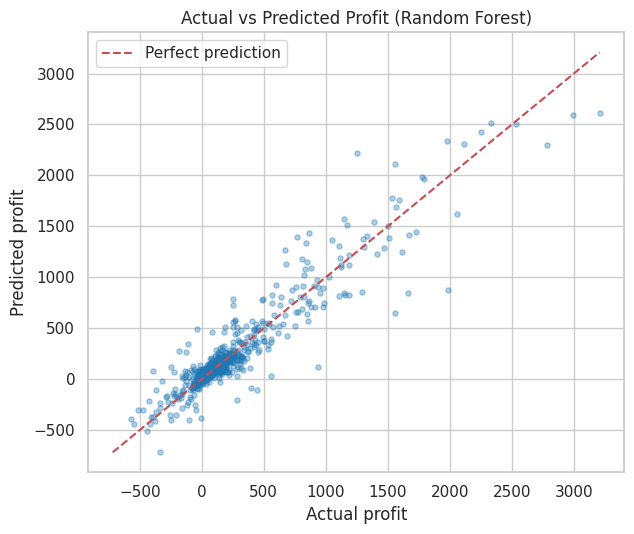

In [15]:
best = results_df.sort_values("R2", ascending=False).iloc[0]["Model"]
print("Best model:", best)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(y_test, preds[best], alpha=0.35, s=14, color="#1f77b4")
lims = [min(y_test.min(), preds[best].min()), max(y_test.max(), preds[best].max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_title(f"Actual vs Predicted Profit ({best})")
ax.set_xlabel("Actual profit"); ax.set_ylabel("Predicted profit")
ax.legend()
plt.tight_layout()
plt.savefig("figures/07_actual_vs_pred.png", dpi=150)
plt.show()

Unit_Price             0.500
Quantity               0.214
Discount               0.203
Category_Technology    0.033
Month                  0.023
Segment_Corporate      0.005
Region_East            0.005
Region_West            0.005
dtype: float64


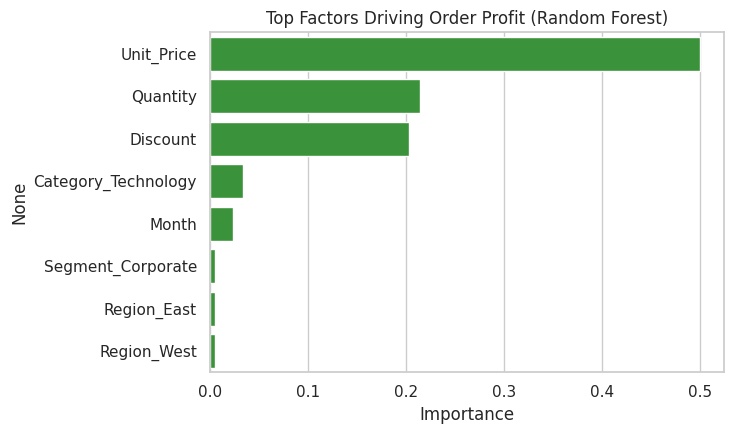

In [16]:
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)

plt.figure(figsize=(7.5, 4.5))
sns.barplot(x=imp.values, y=imp.index, color="#2ca02c")
plt.title("Top Factors Driving Order Profit (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("figures/08_feature_importance.png", dpi=150)
plt.show()
print(imp.round(3))

## 7. Key Insights and Conclusion

In [17]:
cat_margin = (df.groupby("Category")["Profit"].sum() / df.groupby("Category")["Sales"].sum() * 100).round(1)
best_cat = cat_margin.idxmax(); worst_cat = cat_margin.idxmin()
top_region = df.groupby("Region")["Profit"].sum().idxmax()
peak_month = df.groupby("Month")["Sales"].sum().idxmax()
loss_high_disc = (df[df["Discount"] >= 0.20]["Profit"] < 0).mean() * 100
loss_no_disc = (df[df["Discount"] == 0]["Profit"] < 0).mean() * 100
seg_counts = rfm["Segment_Name"].value_counts().to_dict()

print("KEY INSIGHTS")
print("-" * 60)
print(f"1. {best_cat} has the best profit margin ({cat_margin[best_cat]}%); {worst_cat} has the lowest ({cat_margin[worst_cat]}%).")
print(f"2. {top_region} is the most profitable region.")
print(f"3. Sales peak in month {peak_month} (festive/year-end season).")
print(f"4. Orders with 20%+ discount are loss-making {loss_high_disc:.0f}% of the time vs {loss_no_disc:.0f}% with no discount.")
print(f"5. Customer segments found by K-Means: {seg_counts}")
print(f"6. Best prediction model: {best} (R2 = {results_df.set_index('Model').loc[best, 'R2']}).")
print()
print("RECOMMENDATIONS")
print("-" * 60)
print("- Cap discounts at 10% on low-margin categories to protect profit.")
print("- Run retention offers for 'At-Risk / Inactive' customers and loyalty rewards for 'Loyal High-Value' customers.")
print("- Increase stock and marketing before the Oct-Dec peak season.")

KEY INSIGHTS
------------------------------------------------------------
1. Technology has the best profit margin (15.9%); Furniture has the lowest (3.7%).
2. East is the most profitable region.
3. Sales peak in month 12 (festive/year-end season).
4. Orders with 20%+ discount are loss-making 69% of the time vs 1% with no discount.
5. Customer segments found by K-Means: {'Regular': 372, 'Loyal High-Value': 297, 'At-Risk / Inactive': 130}
6. Best prediction model: Random Forest (R2 = 0.882).

RECOMMENDATIONS
------------------------------------------------------------
- Cap discounts at 10% on low-margin categories to protect profit.
- Run retention offers for 'At-Risk / Inactive' customers and loyalty rewards for 'Loyal High-Value' customers.
- Increase stock and marketing before the Oct-Dec peak season.


### Conclusion
The project cleaned a retail sales dataset, explored sales and profit patterns, grouped customers into three behaviour-based segments using K-Means, and predicted order profit with a Random Forest model. The main business lesson is that **heavy discounts reduce profit**, so discount policy and customer-specific retention strategies are the biggest levers for improving results.